# Imports

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import colormaps as cmaps

# map def

In [29]:
def reg_map(ds_to_plt, significance, bounds=[20, -60, 10, -10], name='figure',
           color=cmaps.posneg_1, lcolor='lime',
           lev=np.arange(-1.5, 1.5, 0.15)):

    fig, ax = plt.subplots(1, 1,
                           subplot_kw={'projection': ccrs.PlateCarree()})
    fig.subplots_adjust(hspace=0, wspace=0, top=0.925, left=0.1)
    cbar_ax = fig.add_axes([0, 0, 0.1, 0.1])
    cdat, clon = cutil.add_cyclic_point(ds_to_plt, ds_to_plt.lon)
    csig, csig_lon = cutil.add_cyclic_point(significance, significance.lon)
    # ccomp, ccomp_lon = cutil.add_cyclic_point(comparison, comparison.lon)

    ax.set_title(name)
    lat_ticks = np.arange(bounds[3], bounds[2], 30)
    lon_ticks = np.arange(bounds[1], bounds[0], 60)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)

# local function because it modifies local objects
    def resize_colobar(event):
        plt.draw()
        posn = ax.get_position()
        cbar_ax.set_position([posn.x0 + posn.width + 0.01, posn.y0,
                              0.04, posn.height])

    ax.set_extent(bounds, ccrs.PlateCarree())
    ds_contour = ax.contourf(clon, ds_to_plt.lat, cdat,
                              levels=lev,
                              # levels=40,
                              transform=ccrs.PlateCarree(), cmap=color,
                              extend='both')
    
    ax.contourf(csig_lon, significance.lat, csig,
                transform=ccrs.PlateCarree(),
                levels=[0, 0.05],
                colors='None',
                hatches=['..', ''],
                extend='neither',
                zorder=1)
    
    # ax.contour(ccomp_lon, comparison.lat, ccomp,
    #            transform=ccrs.PlateCarree(),
    #            levels=np.arange(-1, 1, 0.1), extend='both,', colors=lcolor)

    fig.canvas.mpl_connect('resize_event', resize_colobar)
    ax.add_feature(cf.LAND)
    ax.coastlines()
    plt.colorbar(ds_contour, cax=cbar_ax)
    resize_colobar(None)
    # plt.savefig(name, dpi=300)
    plt.show()

# Data select

In [4]:
JJASST_CANI_r = xr.open_dataset('Results/CESM21/JJA_CANI_SST_reg.nc')
JJASST_EANI_r = xr.open_dataset('Results/CESM21/JJA_EANI_SST_reg.nc')
SONSST_CANI_r = xr.open_dataset('Results/CESM21/SON_CANI_SST_reg.nc')
SONSST_EANI_r = xr.open_dataset('Results/CESM21/SON_EANI_SST_reg.nc')

JJAPRECT_CANI_r = xr.open_dataset('Results/CESM21/JJA_CANI_PRECT_reg.nc')
JJAPRECT_EANI_r = xr.open_dataset('Results/CESM21/JJA_EANI_PRECT_reg.nc')
SONPRECT_CANI_r = xr.open_dataset('Results/CESM21/SON_CANI_PRECT_reg.nc')
SONPRECT_EANI_r = xr.open_dataset('Results/CESM21/SON_EANI_PRECT_reg.nc')
# reanalysisC/EANI_SEASONvar_regression
rCANI_JJAprecip_r = xr.open_dataset('Results/Reanalysis/CANI_precip_JJA.nc')
rCANI_SONprecip_r = xr.open_dataset('Results/Reanalysis/CANI_precip_SON.nc')
rEANI_JJAprecip_r = xr.open_dataset('Results/Reanalysis/EANI_precip_JJA.nc')
rEANI_SONprecip_r = xr.open_dataset('Results/Reanalysis/EANI_precip_SON.nc')

rCANI_JJA_SST_r = xr.open_dataset('Results/Reanalysis/CANI_SST_JJA.nc')
rCANI_SON_SST_r = xr.open_dataset('Results/Reanalysis/CANI_SST_SON.nc')
rEANI_JJA_SST_r = xr.open_dataset('Results/Reanalysis/EANI_SST_JJA.nc')
rEANI_SON_SST_r = xr.open_dataset('Results/Reanalysis/EANI_SST_SON.nc')

In [5]:
new_dims = {'longitude': 'lon', 'latitude': 'lat'}

rCANI_JJA_SST_r = rCANI_JJA_SST_r.rename_dims(new_dims)
rCANI_SON_SST_r = rCANI_SON_SST_r.rename_dims(new_dims)
rEANI_JJA_SST_r = rEANI_JJA_SST_r.rename_dims(new_dims)
rEANI_SON_SST_r = rEANI_SON_SST_r.rename_dims(new_dims)

In [6]:
# rCANI_JJA_SST_r = rCANI_JJA_SST_r.sortby(rCANI_JJA_SST_r.lat)
# rCANI_SON_SST_r = rCANI_SON_SST_r.sortby(rCANI_SON_SST_r.lat)
# rEANI_JJA_SST_r = rEANI_JJA_SST_r.sortby(rCANI_JJA_SST_r.lat)
# rEANI_SON_SST_r = rEANI_SON_SST_r.sortby(rEANI_SON_SST_r.lat)

# Select only significant values of reanalysis

In [7]:
rCANI_JJA_SST_r

<xarray.Dataset> Size: 2MB
Dimensions:    (lat: 180, lon: 360)
Coordinates:
  * latitude   (lat) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (lon) float32 1kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Dimensions without coordinates: lat, lon
Data variables:
    cov        (lat, lon) float32 259kB ...
    cor        (lat, lon) float32 259kB ...
    r2         (lat, lon) float32 259kB ...
    slope      (lat, lon) float32 259kB ...
    intercept  (lat, lon) float32 259kB ...
    pvalue     (lat, lon) float32 259kB ...
    stderr     (lat, lon) float32 259kB ...
    n          (lat, lon) int16 130kB ...

In [8]:
rCANI_JJAprecip_slope_sig = rCANI_JJAprecip_r['slope'].where(rCANI_JJAprecip_r['pvalue'] <= 0.05)
rCANI_SONprecip_slope_sig = rCANI_SONprecip_r['slope'].where(rCANI_SONprecip_r['pvalue'] <= 0.05)
rEANI_JJAprecip_slope_sig = rEANI_JJAprecip_r['slope'].where(rEANI_JJAprecip_r['pvalue'] <= 0.05)
rEANI_SONprecip_slope_sig = rEANI_SONprecip_r['slope'].where(rEANI_SONprecip_r['pvalue'] <= 0.05)

rCANI_JJA_SST_slope_sig = rCANI_JJA_SST_r['slope'].where(rCANI_JJA_SST_r['pvalue'] <= 0.05)
rCANI_SON_SST_slope_sig = rCANI_SON_SST_r['slope'].where(rCANI_SON_SST_r['pvalue'] <= 0.05)
rEANI_JJA_SST_slope_sig = rEANI_JJA_SST_r['slope'].where(rEANI_JJA_SST_r['pvalue'] <= 0.05)
rEANI_SON_SST_slope_sig = rEANI_SON_SST_r['slope'].where(rEANI_SON_SST_r['pvalue'] <= 0.05)

# Ensemble means

In [30]:
JJASST_EANI_r

<xarray.Dataset> Size: 166MB
Dimensions:    (member: 100, lat: 192, lon: 288)
Coordinates:
  * member     (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
Data variables:
    cov        (member, lat, lon) float32 22MB 0.0 0.0 ... -0.0001272 -0.0001256
    cor        (member, lat, lon) float32 22MB nan nan ... -0.002192 -0.002165
    r2         (member, lat, lon) float32 22MB nan nan ... 4.804e-06 4.685e-06
    slope      (member, lat, lon) float32 22MB 0.0 0.0 ... -0.0002181 -0.0002154
    intercept  (member, lat, lon) float32 22MB 0.0 0.0 0.0 ... 271.4 271.4 271.4
    pvalue     (member, lat, lon) float32 22MB nan nan nan ... 0.9697 0.9701
    stderr     (member, lat, lon) float32 22MB nan nan nan ... 0.005735 0.005735
    n          (member, lat, lon) int16 11MB 303 303 303 303 ... 303 303 303 303

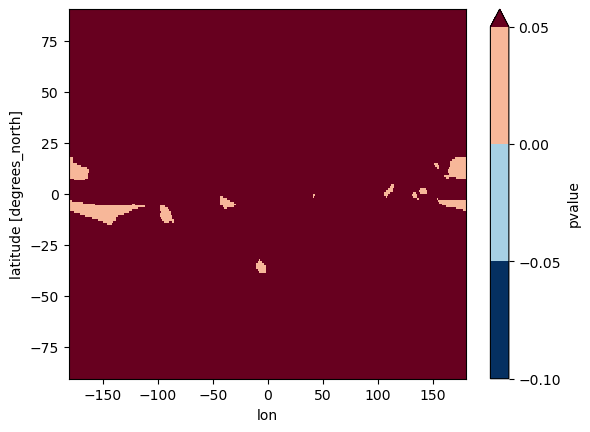

In [48]:
testmem = JJAPRECT_CANI_r['pvalue'].mean('member')
#testmem.where(testmem<=0.05)
testmem.plot(levels=np.arange(-0.1,0.1, 0.05))

In [9]:
ens_jja_sstvEANI = JJASST_EANI_r.mean(dim='member')
ens_jja_sstvCANI = JJASST_CANI_r.mean(dim='member')
ens_son_sstvEANI = SONSST_EANI_r.mean(dim='member')
ens_son_sstvCANI = SONSST_CANI_r.mean(dim='member')

ens_jja_PRECTvCANI = JJAPRECT_CANI_r.mean(dim='member')
ens_jja_PRECTvEANI = JJAPRECT_EANI_r.mean(dim='member')
ens_son_PRECTvCANI = SONPRECT_CANI_r.mean(dim='member')
ens_son_PRECTvEANI = SONPRECT_EANI_r.mean(dim='member')

In [10]:
ens_jja_sstvEANI

<xarray.Dataset> Size: 2MB
Dimensions:    (lat: 192, lon: 288)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
Data variables:
    cov        (lat, lon) float32 221kB 0.0 0.0 0.0 ... 0.003832 0.003831
    cor        (lat, lon) float32 221kB nan nan nan ... 0.05674 0.05674 0.05674
    r2         (lat, lon) float32 221kB nan nan nan ... 0.004376 0.004376
    slope      (lat, lon) float32 221kB 0.0 0.0 0.0 ... 0.005073 0.005072
    intercept  (lat, lon) float32 221kB 0.0 0.0 0.0 0.0 ... 271.4 271.4 271.4
    pvalue     (lat, lon) float32 221kB nan nan nan nan ... 0.3763 0.3763 0.3763
    stderr     (lat, lon) float32 221kB nan nan nan ... 0.005132 0.005131
    n          (lat, lon) float64 442kB 303.0 303.0 303.0 ... 303.0 303.0 303.0

In [11]:
test = JJAPRECT_EANI_r.sel(member=1)
cont = test.slope * 1000 * (24*60*60)
reg_map(cont, test.pvalue, bounds=[-180, 180, -90, 90], name='CESM21_SSTvEANI_JJA')

TypeError: reg_map() missing 1 required positional argument: 'comparison'

# Plots

In [ ]:
rEANI_JJA_SST_slope_sig.plot(levels=np.arange(-1, 1, 0.1))

In [ ]:
reg_map(ens_jja_sstvEANI.slope, ens_jja_sstvEANI.pvalue, rEANI_JJA_SST_slope_sig,
        bounds=[-180, 180, -90, 90], name='JJA SST EANI slope')

In [ ]:
reg_map(ens_jja_sstvCANI.slope, ens_jja_sstvCANI.pvalue, bounds=[-180, 180, -90, 90], name='CESM21_SSTvCANI_JJA')

In [ ]:
reg_map(ens_son_sstvEANI.slope, ens_son_sstvEANI.pvalue, bounds=[-180, 180, -90, 90], name='CESM21_SSTvEANI_SON')

In [ ]:
reg_map(ens_son_sstvCANI.slope, ens_son_sstvCANI.pvalue, bounds=[-180, 180, -90, 90], name='CESM21_SSTvCANI_SON')

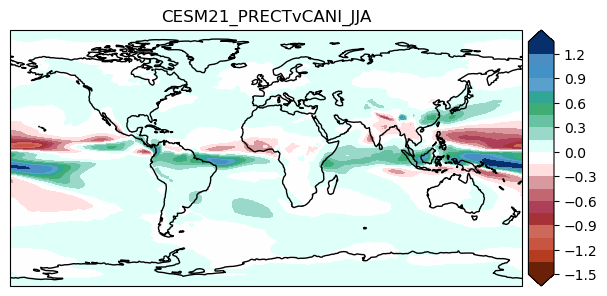

In [28]:
# conversion from m/s to mm/day
ens_jja_PRECTvCANI_con = ens_jja_PRECTvCANI.slope * 1000 * (24*60*60)

reg_map(ens_jja_PRECTvCANI_con, ens_jja_PRECTvCANI.pvalue,
        bounds=[-180, 180, -90, 90], name='CESM21_PRECTvCANI_JJA',
        color=cmaps.precip4_diff_19lev)

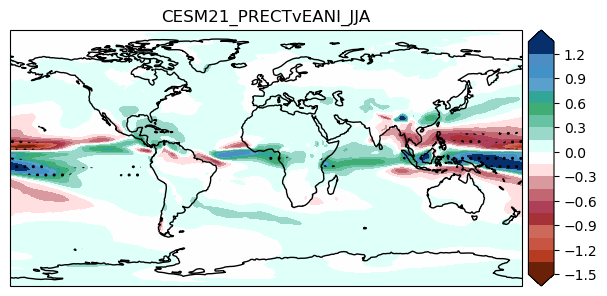

In [18]:
ens_jja_PRECTvEANI_con = ens_jja_PRECTvEANI.slope * 1000 * (24*60*60)

reg_map(ens_jja_PRECTvEANI_con, ens_jja_PRECTvEANI.pvalue,
        bounds=[-180, 180, -90, 90], name='CESM21_PRECTvEANI_JJA',
        color=cmaps.precip4_diff_19lev)

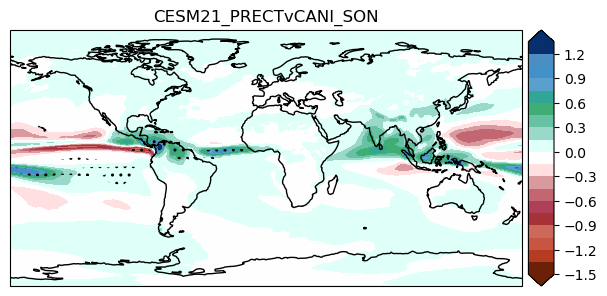

In [19]:
ens_son_PRECTvCANI_con = ens_son_PRECTvCANI.slope * 1000 * (24 * 60 * 60)

reg_map(ens_son_PRECTvCANI_con, ens_son_PRECTvCANI.pvalue,
        bounds=[-180, 180, -90, 90], name='CESM21_PRECTvCANI_SON',
        color=cmaps.precip4_diff_19lev)

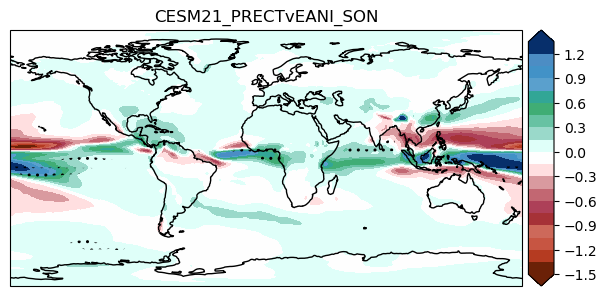

In [20]:
ens_son_PRECTvEANI_con = ens_jja_PRECTvEANI.slope * 1000 * ( 24 * 60 * 60)

reg_map(ens_son_PRECTvEANI_con, ens_son_PRECTvEANI.pvalue,
        bounds=[-180, 180, -90, 90], name='CESM21_PRECTvEANI_SON',
        color=cmaps.precip4_diff_19lev)